<a href="https://colab.research.google.com/github/z55vz/DL_Project/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



=== MODEL PERFORMANCE SUMMARY ===


,Model,AUC,Brier Score
0,Logistic Regression,0.945243,0.090581
1,Deep Neural Network,0.957171,0.083638



=== RANDOM SAMPLE OF PREDICTIONS ===


,distance,is_peak,is_rainy,price,p_base,True_Label,LR_Prob,DNN_Prob
280804,8.000000,0,0,13.854986,14.400000,0,0.615606,0.723294
379255,5.088889,0,0,9.234564,12.071111,1,0.918265,0.929800
353806,3.666667,1,0,6.361215,10.933333,1,0.980152,0.931303
52927,8.988889,0,0,17.669719,15.191111,0,0.109277,0.005180
4009,6.833333,0,0,7.417340,13.466667,1,0.994220,0.999709
247990,2.566667,0,0,12.248591,10.053333,0,0.135351,0.315618
144178,5.044444,1,1,7.050499,12.035556,1,0.985765,0.996042
101082,9.466667,0,1,9.564776,15.573333,1,0.993938,0.999995
249551,6.911111,0,0,19.678134,13.528889,0,0.005403,0.000197
357831,6.822222,0,0,11.323840,13.457778,1,0.860724,0.950682


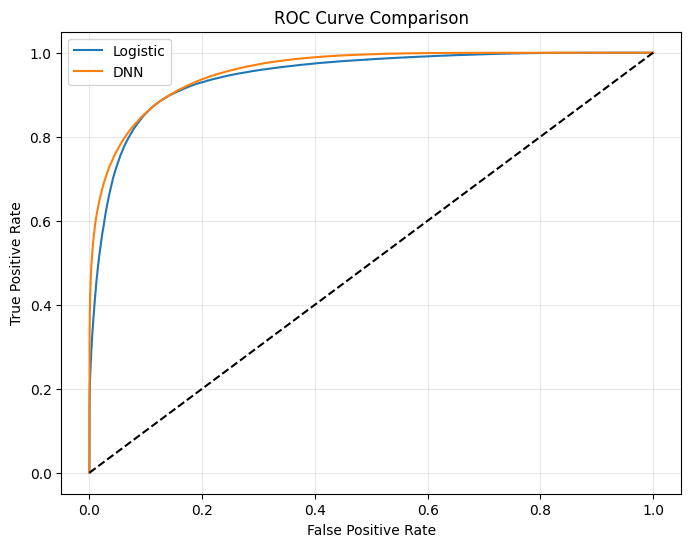

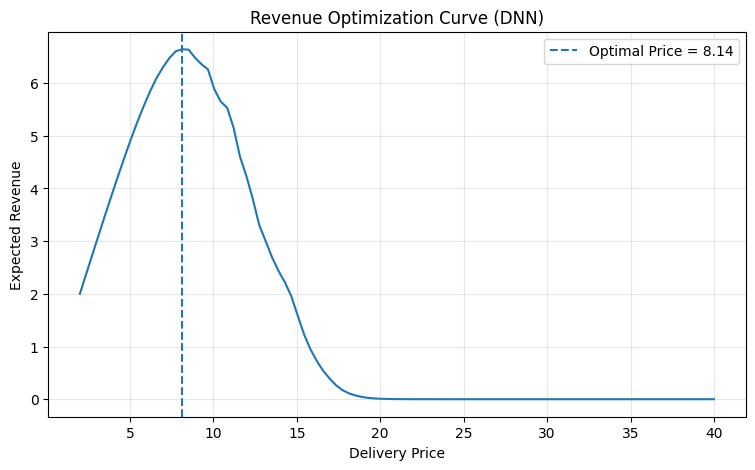

In [ ]:
# =============================================================================
# PROJECT: Context-Aware Revenue Optimization in Food Delivery Platforms
# AUTHOR: Abdulrahman Jaber Ageeli
# DESCRIPTION:
#   Logistic Regression vs Deep Neural Network for stochastic
#   demand modeling in a simulated context-aware market.
# =============================================================================

# =============================================================================
# 1. Reproducibility & Imports
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

# =============================================================================
# 2. Load and Prepare Base Dataset
# =============================================================================
DATA_PATH = "historical_data.csv"
df = pd.read_csv(DATA_PATH)

required_cols = [
    "created_at",
    "estimated_store_to_consumer_driving_duration"
]

df = df[required_cols].dropna()

# Convert timestamp
df["created_at"] = pd.to_datetime(df["created_at"])
df["hour"] = df["created_at"].dt.hour

# Define peak windows
df["is_peak"] = (
    ((df["hour"] >= 11) & (df["hour"] <= 14)) |
    ((df["hour"] >= 18) & (df["hour"] <= 21))
).astype(int)

# Distance proxy (km)
AVG_CITY_SPEED = 40
df["distance_km"] = (
    df["estimated_store_to_consumer_driving_duration"] / 3600
) * AVG_CITY_SPEED

df = df[df["distance_km"] > 0]

# Simulated weather
rain_prob = 0.2 + 0.1 * df["is_peak"]
df["is_rainy"] = (np.random.rand(len(df)) < rain_prob).astype(int)

# =============================================================================
# 3. Dynamic Base Price Model
# =============================================================================
def compute_base_price(distance):
    return 8 + 0.8 * distance

df["p_base"] = compute_base_price(df["distance_km"])

# =============================================================================
# 4. Split BEFORE Expansion (Prevents Data Leakage)
# =============================================================================
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42
)

# =============================================================================
# 5. Stochastic Market Simulator
# =============================================================================
def simulate_market(dataframe, n_prices=10):

    rows = []

    for _, r in dataframe.iterrows():

        alpha = (
            0.15
            + 0.05 * r.distance_km
            + 0.02 * (r.distance_km ** 2)
            + 0.08 * r.distance_km * r.is_rainy
            - 0.07 * r.is_peak
        )

        for _ in range(n_prices):

            delta = np.random.uniform(-0.5 * r.p_base, 0.5 * r.p_base)
            price = max(2.0, r.p_base + delta)

            epsilon = np.random.normal(0, 0.5)
            z = -alpha * (price - r.p_base) + epsilon
            p_accept = 1 / (1 + np.exp(-z))

            accepted = np.random.rand() < p_accept

            rows.append({
                "distance": r.distance_km,
                "is_peak": r.is_peak,
                "is_rainy": r.is_rainy,
                "price": price,
                "p_base": r.p_base,
                "target": int(accepted)
            })

    return pd.DataFrame(rows)

train_sim = simulate_market(train_df)
test_sim  = simulate_market(test_df)

# =============================================================================
# 6. Feature Matrix
# =============================================================================
features = ["distance", "is_peak", "is_rainy", "price", "p_base"]

X_train = train_sim[features]
y_train = train_sim["target"]

X_test = test_sim[features]
y_test = test_sim["target"]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# =============================================================================
# 7. Logistic Regression (Baseline)
# =============================================================================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
lr_probs = lr.predict_proba(X_test_s)[:, 1]

# =============================================================================
# 8. Deep Neural Network
# =============================================================================
dnn = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_s.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

dnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

dnn.fit(
    X_train_s, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=128,
    callbacks=[early_stop],
    verbose=0
)

dnn_probs = dnn.predict(X_test_s, verbose=0).ravel()

# =============================================================================
# 9. Model Performance Summary
# =============================================================================
results_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Deep Neural Network"],
    "AUC": [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, dnn_probs)
    ],
    "Brier Score": [
        brier_score_loss(y_test, lr_probs),
        brier_score_loss(y_test, dnn_probs)
    ]
})

print("\n=== MODEL PERFORMANCE SUMMARY ===")
display(results_table)

# =============================================================================
# 10. Sample Predictions (Random for Better Representation)
# =============================================================================
evaluation_sample = X_test.copy()
evaluation_sample["True_Label"] = y_test.values
evaluation_sample["LR_Prob"] = lr_probs
evaluation_sample["DNN_Prob"] = dnn_probs

print("\n=== RANDOM SAMPLE OF PREDICTIONS ===")
display(evaluation_sample.sample(10, random_state=42))

# =============================================================================
# 11. ROC Curve Comparison
# =============================================================================
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_dnn, tpr_dnn, _ = roc_curve(y_test, dnn_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label="Logistic")
plt.plot(fpr_dnn, tpr_dnn, label="DNN")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# =============================================================================
# 12. Revenue Optimization (DNN Demonstration)
# =============================================================================
example = X_test.iloc[[0]].copy()
price_grid = np.linspace(2, 40, 100)

revenues = []

for p in price_grid:
    example["price"] = p
    prob = dnn.predict(scaler.transform(example), verbose=0)[0,0]
    revenues.append(p * prob)

best_price = price_grid[np.argmax(revenues)]

plt.figure(figsize=(9,5))
plt.plot(price_grid, revenues)
plt.axvline(best_price, linestyle="--", label=f"Optimal Price = {best_price:.2f}")
plt.xlabel("Delivery Price")
plt.ylabel("Expected Revenue")
plt.title("Revenue Optimization Curve (DNN)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()